In [76]:
# Importing necessary libraries and suppressing warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # use Agg backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # if only plt is used

%matplotlib inline

import seaborn as sns

from imblearn.over_sampling import SMOTE

# Scikit-learn libraries for predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import xgboost as xgb

from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier

# Set visualization style
sns.set(style='whitegrid')

# Print a simple log to verify imports (for notebook builders debugging purposes)
print('Libraries imported and configured')

Libraries imported and configured


In [77]:
# Data Loading and Preprocessing
print('Loading data...')

# Load the CSV version of the dataset
csv_path = 'H:/Documentos/Freelance e Projetos/Educacional/Spotify Churn/spotify_churn_dataset.csv'
df_csv = pd.read_csv(csv_path, encoding='utf-8', delimiter=',')

# Use the CSV dataset for analysis
df = df_csv.copy()

print('Data loaded. Shape:', df.shape)

# Quick look at the data
display(df.head())

# Check the data types
print('Data types:')
print(df.dtypes)

Loading data...
Data loaded. Shape: (8000, 12)


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


Data types:
user_id                    int64
gender                    object
age                        int64
country                   object
subscription_type         object
listening_time             int64
songs_played_per_day       int64
skip_rate                float64
device_type               object
ads_listened_per_week      int64
offline_listening          int64
is_churned                 int64
dtype: object


In [78]:
#Check missing values
missing_values = df.isnull().sum()
print(missing_values)


user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64


Beginning exploratory data analysis...


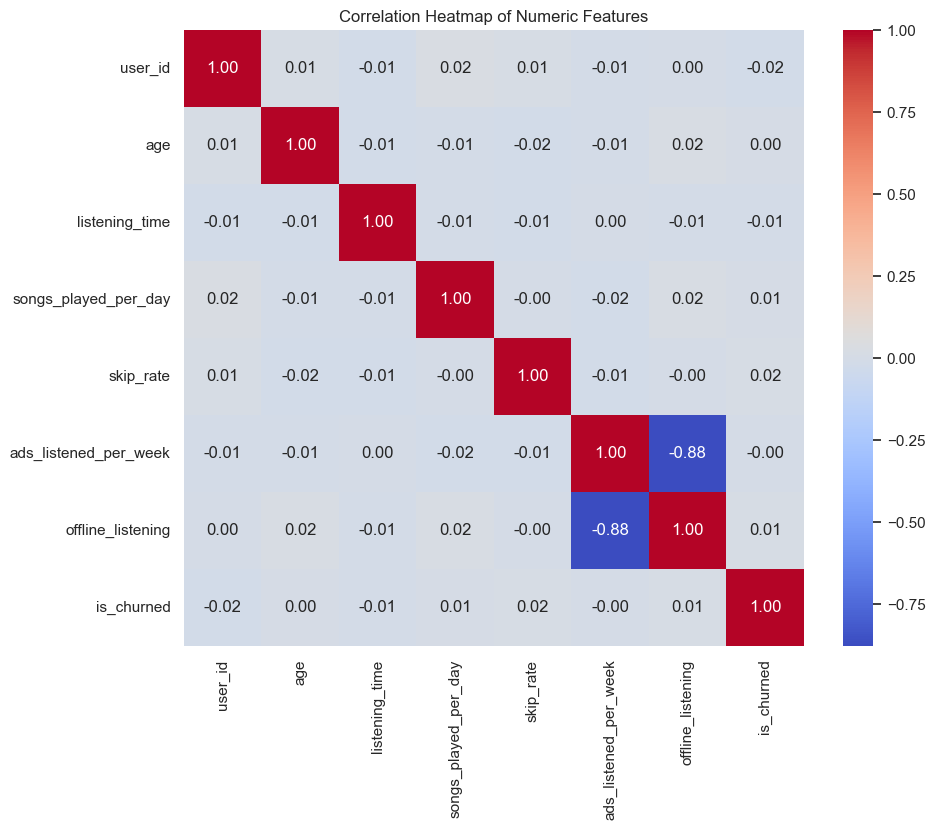

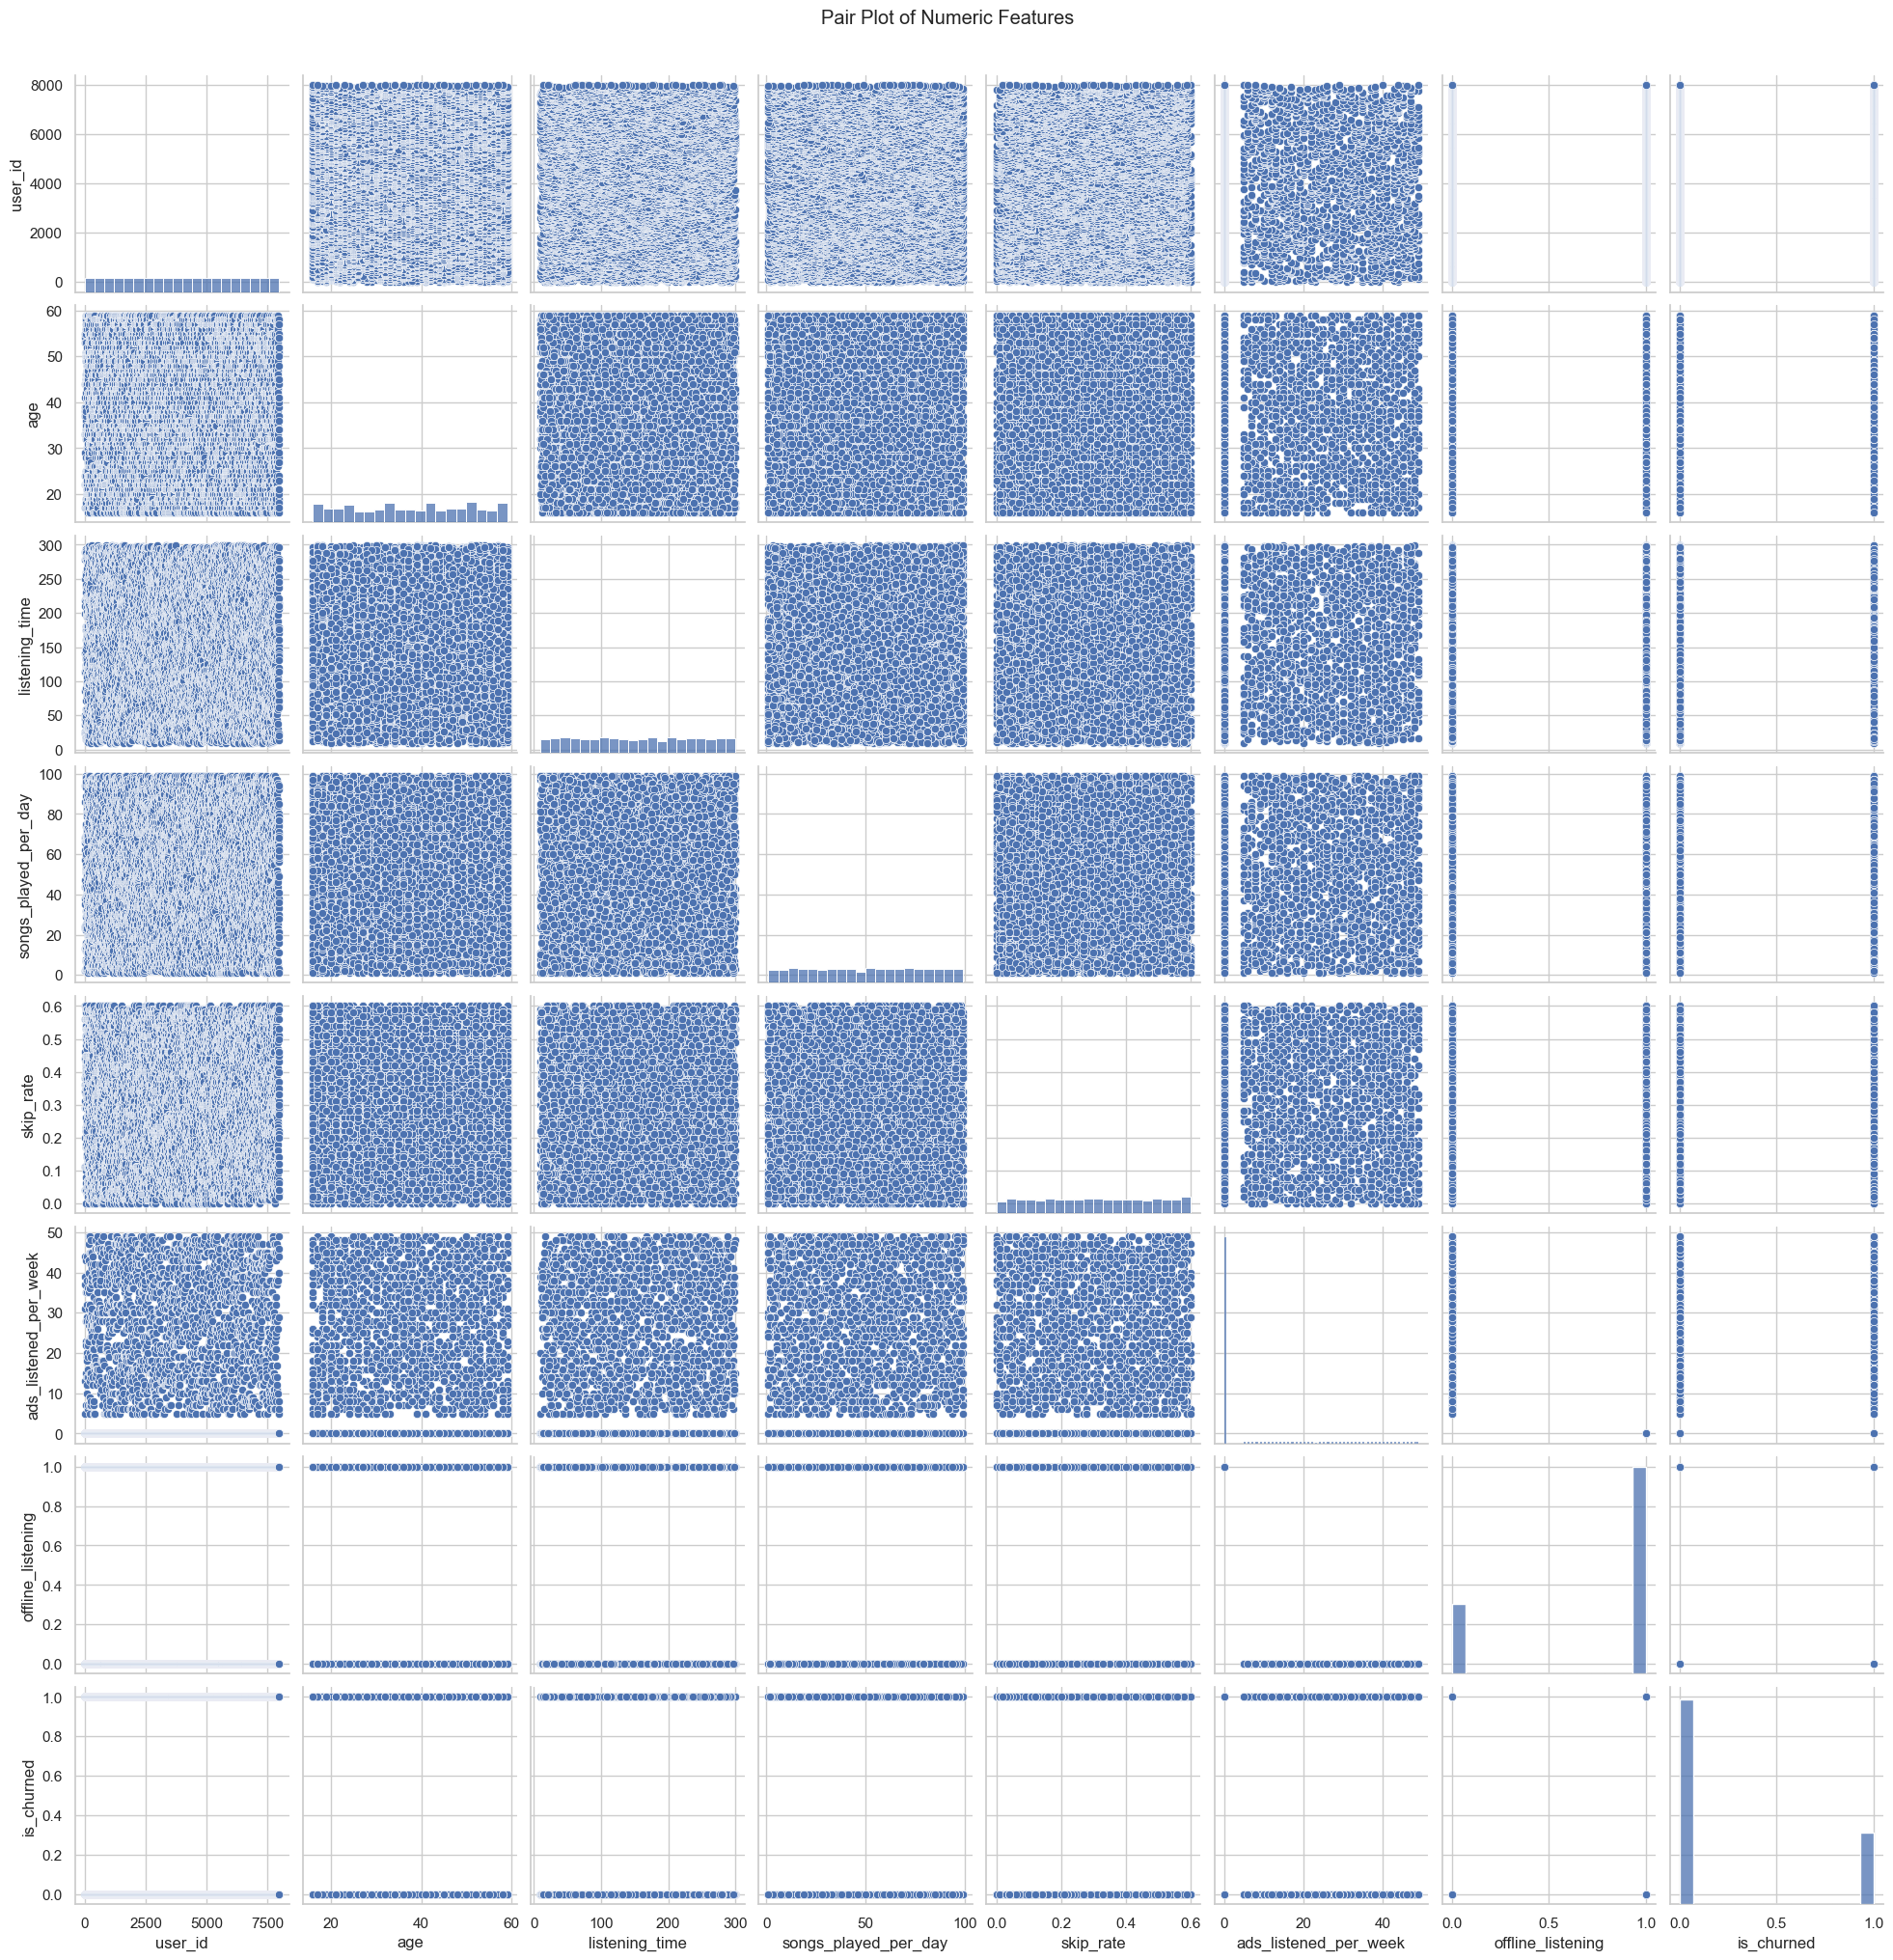

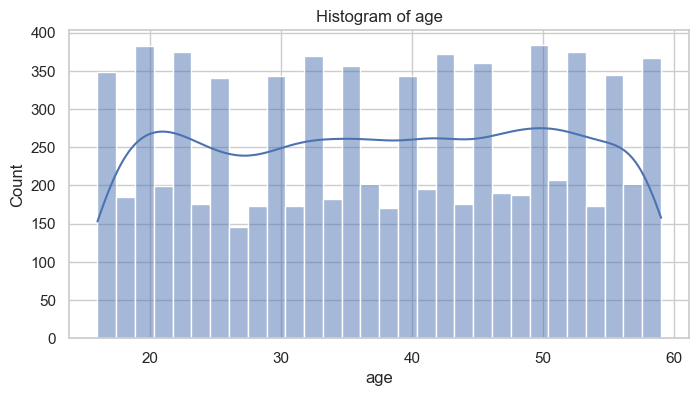

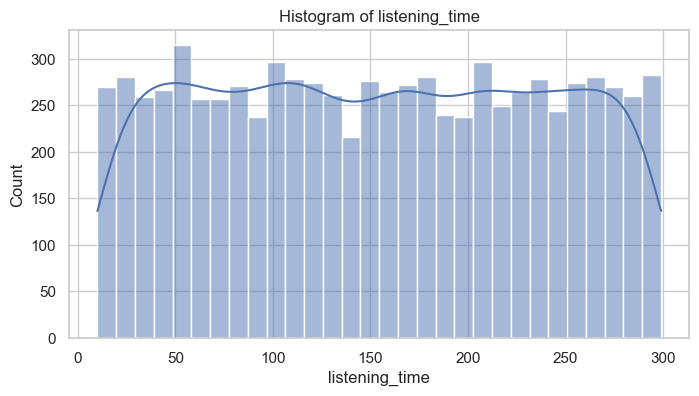

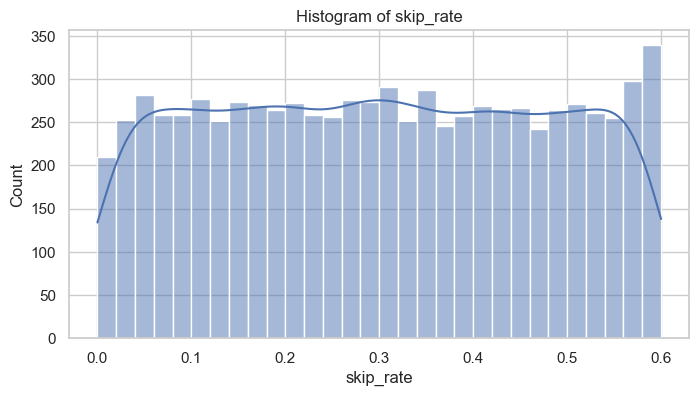

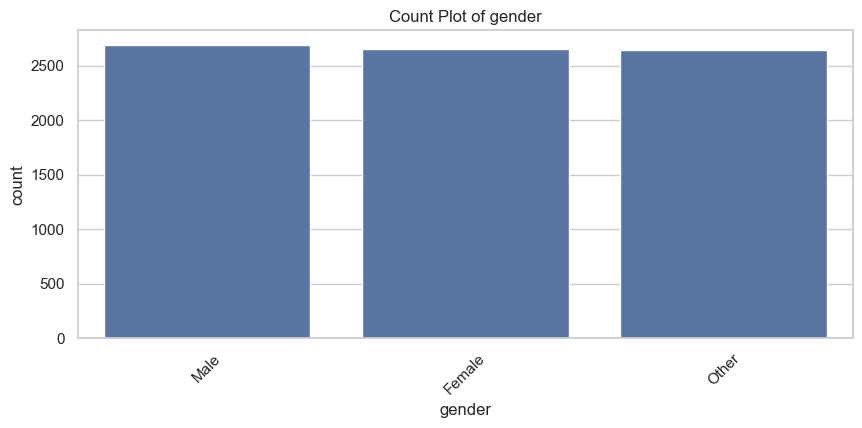

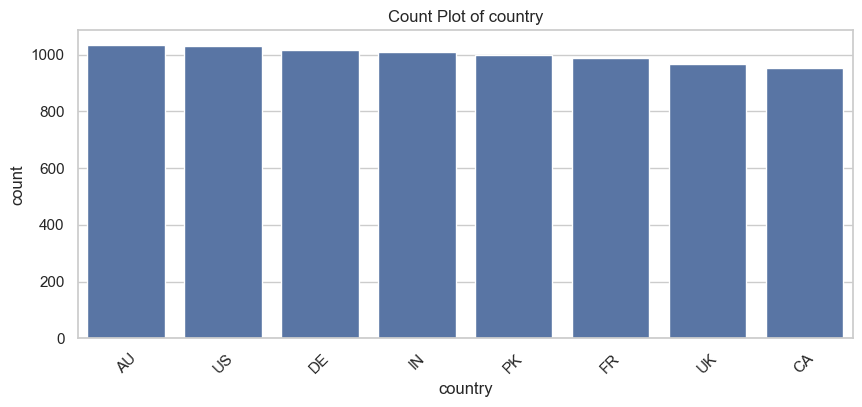

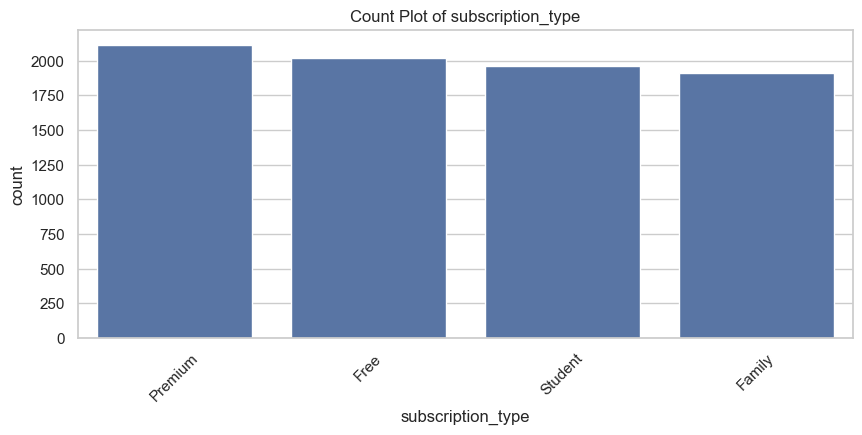

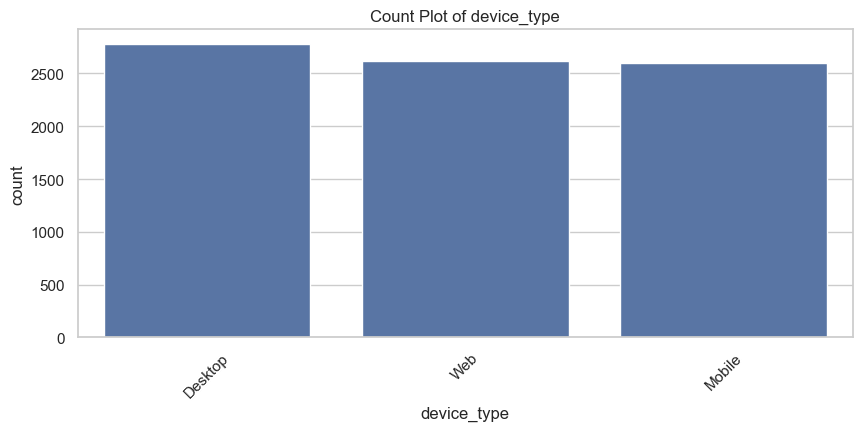

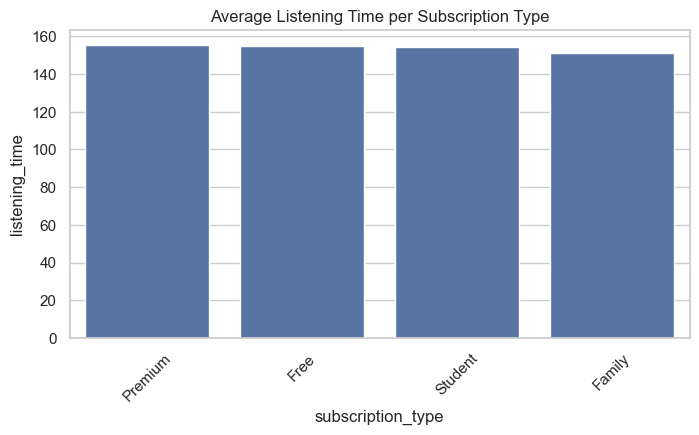

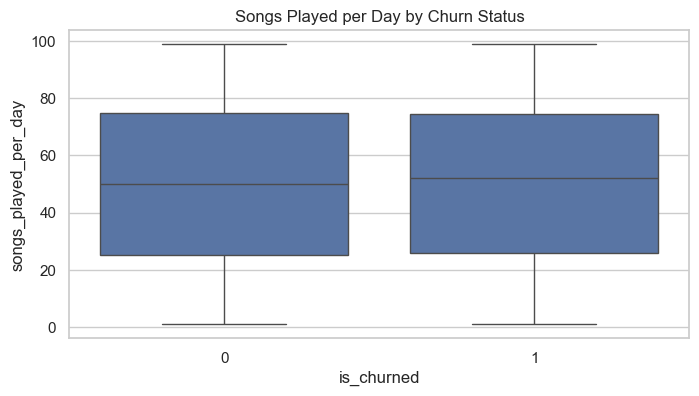

In [79]:
# Exploratory Data Analysis
print('Beginning exploratory data analysis...')

## Correlation Heatmap (for numeric features)
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
# Check the number of numeric columns
if len(numeric_df.columns) >= 4:
    plt.figure(figsize=(10, 8))
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.savefig('correlation_heatmap.png')
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

# Pair Plot of numeric features
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.savefig('pairplot_numeric.png')
plt.show()

# Histograms for selected numeric features
features_to_hist = ['age', 'listening_time', 'skip_rate']
for feature in features_to_hist:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Histogram of {feature}')
    plt.savefig(f'hist_{feature}.png')
    plt.show()

# Count plots for categorical variables
categorical_cols = ['gender', 'country', 'subscription_type', 'device_type']
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.savefig(f'countplot_{col}.png')
    plt.show()

# Grouped barplot: Average listening time per subscription type
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='subscription_type', y='listening_time', ci=None, order=df['subscription_type'].value_counts().index)
plt.title('Average Listening Time per Subscription Type')
plt.xticks(rotation=45)
plt.savefig('grouped_bar_subscription.png')
plt.show()

# Box plot for songs played per day by churn status
plt.figure(figsize=(8, 4))
sns.boxplot(x='is_churned', y='songs_played_per_day', data=df)
plt.title('Songs Played per Day by Churn Status')
plt.savefig('boxplot_songs_churn.png')
plt.show()

In [80]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [81]:
df_model = df.drop('user_id', axis=1)

categorical_features = ['gender', 'country', 'subscription_type', 'device_type']

df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

df_encoded.head()

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,gender_Male,gender_Other,country_CA,...,country_FR,country_IN,country_PK,country_UK,country_US,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Mobile,device_type_Web
0,54,26,23,0.20,31,0,1,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,33,141,62,0.34,0,1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
2,38,199,38,0.04,0,1,1,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,22,36,2,0.31,0,1,0,False,False,True,...,False,False,False,False,False,False,False,True,True,False
4,29,250,57,0.36,0,1,1,False,True,False,...,False,False,False,False,True,False,False,False,True,False


In [82]:
# Define target(y) and features(X)
X = df_encoded.drop('is_churned', axis=1)
y = df_encoded['is_churned']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Accuracy of Logistic Regression model: 0.7491666666666666


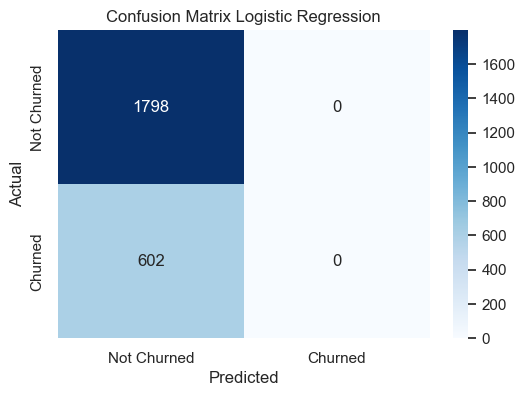

              precision    recall  f1-score   support

 Not Churned       0.75      1.00      0.86      1798
     Churned       0.00      0.00      0.00       602

    accuracy                           0.75      2400
   macro avg       0.37      0.50      0.43      2400
weighted avg       0.56      0.75      0.64      2400



In [83]:
# LOGISTIC REGRESSION

# Model Training and Evaluation
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# Predictions
y_pred = model_lr.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Logistic Regression model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Logistic Regression')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Accuracy of Random Forest model: 0.745


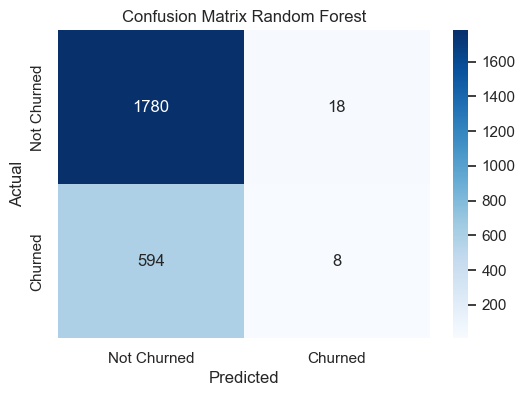

              precision    recall  f1-score   support

 Not Churned       0.75      0.99      0.85      1798
     Churned       0.31      0.01      0.03       602

    accuracy                           0.74      2400
   macro avg       0.53      0.50      0.44      2400
weighted avg       0.64      0.74      0.65      2400



In [84]:
# RANDOM FOREST

# Model Training and Evaluation
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Predictions
y_pred = model_rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Random Forest model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Random Forest')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Valor do scale_pos_weight: 2.81
Accuracy of XGBoost model: 0.61


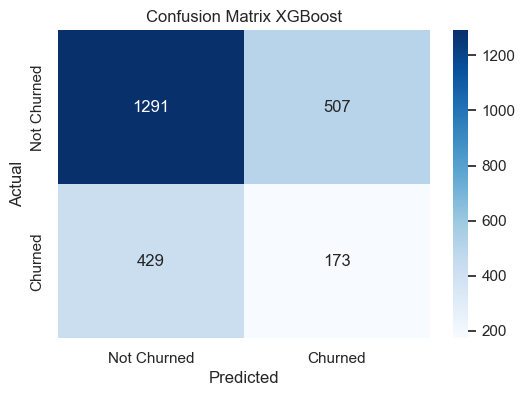

              precision    recall  f1-score   support

 Not Churned       0.75      0.72      0.73      1798
     Churned       0.25      0.29      0.27       602

    accuracy                           0.61      2400
   macro avg       0.50      0.50      0.50      2400
weighted avg       0.63      0.61      0.62      2400



In [85]:
# XGBoost

# Classe negativa = 0 (Not Churned), Classe positiva = 1 (Churned)
count_neg, count_pos = np.bincount(y_train)
scale_pos_weight_value = count_neg / count_pos

print(f"Valor do scale_pos_weight: {scale_pos_weight_value:.2f}")

# Model Training and Evaluation com XGBoost
# Nota: usei 'use_label_encoder=False' e 'eval_metric='logloss'' para evitar warnings comuns.
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value, # Parâmetro chave para balanceamento!
    use_label_encoder=False,
    eval_metric='logloss'
)


model_xgb.fit(X_train, y_train)

# Predictions
y_pred = model_xgb.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of XGBoost model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix XGBoost')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

In [86]:
# LogisticRegression and RandomForest models predict almost everything "Not Churned", so I will investigate why

# Distribution of 'y' variable
print(y.value_counts(normalize=True))

is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64


Accuracy of Logistic Regression model: 0.5029166666666667


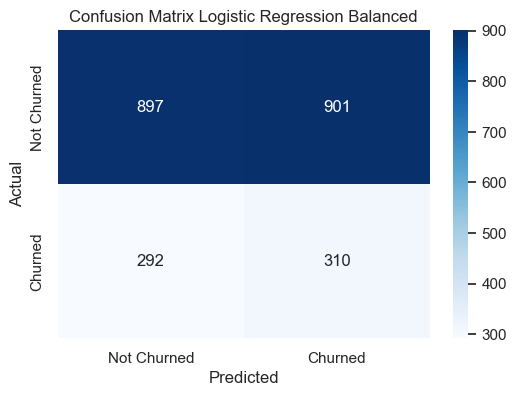

              precision    recall  f1-score   support

 Not Churned       0.75      0.50      0.60      1798
     Churned       0.26      0.51      0.34       602

    accuracy                           0.50      2400
   macro avg       0.51      0.51      0.47      2400
weighted avg       0.63      0.50      0.54      2400



In [87]:
# LOGISTIC REGRESSION

# Model Training and Evaluation
#changed class weight
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_train, y_train)

# Predictions
y_pred = model_lr.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Logistic Regression model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Logistic Regression Balanced')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Accuracy of Random Forest model: 0.74875


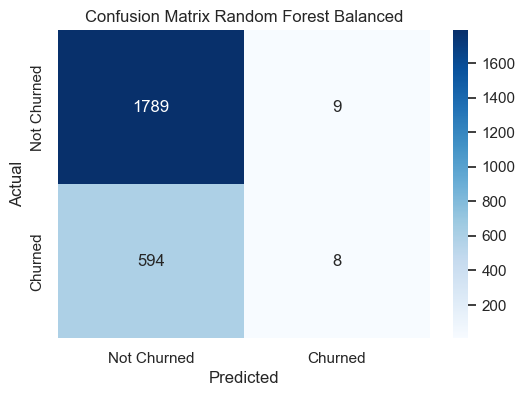

              precision    recall  f1-score   support

 Not Churned       0.75      0.99      0.86      1798
     Churned       0.47      0.01      0.03       602

    accuracy                           0.75      2400
   macro avg       0.61      0.50      0.44      2400
weighted avg       0.68      0.75      0.65      2400



In [88]:
# RANDOM FOREST

# Model Training and Evaluation
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

# Predictions
y_pred = model_rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Random Forest model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Random Forest Balanced')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

In [89]:
# By putting "class_weight" in both models, the LogisticRegression improved, but Random Forest didn't. Let's do SMOTE

# 1. Divida os dados ANTES de aplicar o SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 
# Usar stratify=y é uma boa prática para manter a proporção das classes na divisão

# 2. Aplique o SMOTE APENAS nos dados de treino
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição antes do SMOTE:")
print(y_train.value_counts())

print("\nDistribuição depois do SMOTE:")
print(y_train_resampled.value_counts())

Distribuição antes do SMOTE:
is_churned
0    4150
1    1450
Name: count, dtype: int64

Distribuição depois do SMOTE:
is_churned
0    4150
1    4150
Name: count, dtype: int64


Accuracy of Logistic Regression model: 0.6320833333333333


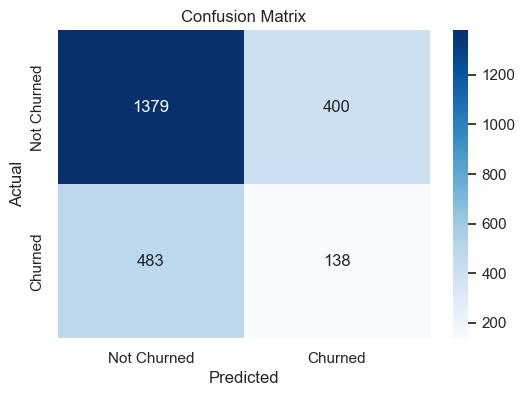

              precision    recall  f1-score   support

 Not Churned       0.74      0.78      0.76      1779
     Churned       0.26      0.22      0.24       621

    accuracy                           0.63      2400
   macro avg       0.50      0.50      0.50      2400
weighted avg       0.62      0.63      0.62      2400



In [90]:
# LOGISTIC REGRESSION WITH SMOTE

# Model Training and Evaluation
#changed class weight
model_lr_smote = LogisticRegression(max_iter=1000)
model_lr_smote.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred = model_lr_smote.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Logistic Regression model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Accuracy of Random Forest model: 0.70125


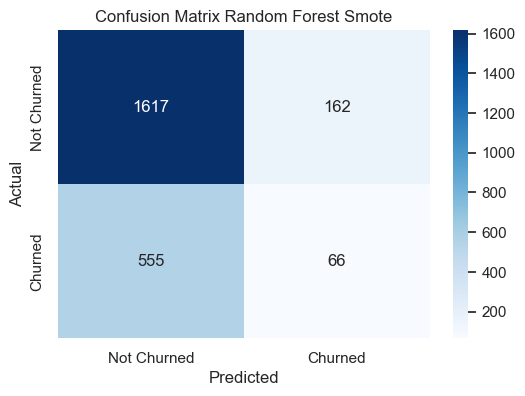

              precision    recall  f1-score   support

 Not Churned       0.74      0.91      0.82      1779
     Churned       0.29      0.11      0.16       621

    accuracy                           0.70      2400
   macro avg       0.52      0.51      0.49      2400
weighted avg       0.63      0.70      0.65      2400



In [91]:
# RANDOM FOREST WITH SMOTE

# Model Training and Evaluation
model_rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_smote.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred = model_rf_smote.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Random Forest model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Random Forest Smote')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Valor do scale_pos_weight: 1.00
Accuracy of XGBoost model: 0.68


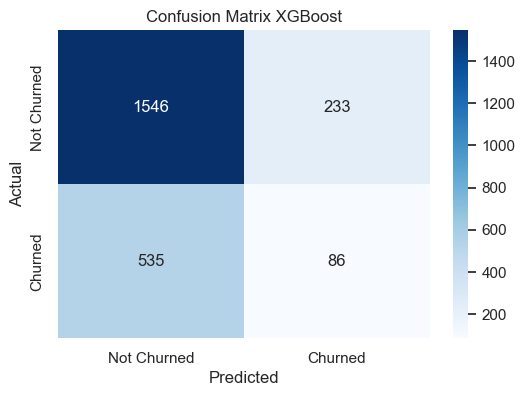

              precision    recall  f1-score   support

 Not Churned       0.74      0.87      0.80      1779
     Churned       0.27      0.14      0.18       621

    accuracy                           0.68      2400
   macro avg       0.51      0.50      0.49      2400
weighted avg       0.62      0.68      0.64      2400



In [92]:
# XGBoost

# Classe negativa = 0 (Not Churned), Classe positiva = 1 (Churned)
count_neg, count_pos = np.bincount(y_train_resampled)
scale_pos_weight_value = count_neg / count_pos

print(f"Valor do scale_pos_weight: {scale_pos_weight_value:.2f}")

# Model Training and Evaluation com XGBoost
# Nota: usei 'use_label_encoder=False' e 'eval_metric='logloss'' para evitar warnings comuns.
model_xgb_smote = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value, # Parâmetro chave para balanceamento!
    use_label_encoder=False,
    eval_metric='logloss'
)


model_xgb_smote.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred = model_xgb_smote.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of XGBoost model:', accuracy)

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix XGBoost')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Treinando o modelo de ensemble...
Treinamento concluído!

--- Relatório de Classificação do Ensemble (Voting) ---
              precision    recall  f1-score   support

 Not Churned       0.74      0.92      0.82      1779
     Churned       0.27      0.08      0.12       621

    accuracy                           0.70      2400
   macro avg       0.50      0.50      0.47      2400
weighted avg       0.62      0.70      0.64      2400



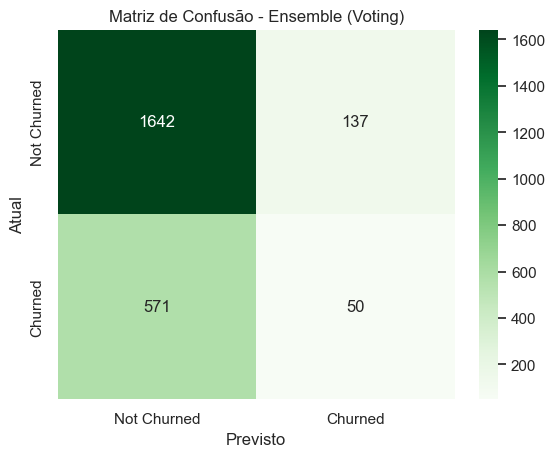

In [93]:
# ENSEMBLE MODEL WITH VOTING CLASSIFIER

# --- 1. Defina seus modelos base ---
# É importante que os modelos não estejam treinados ainda.
# O VotingClassifier cuidará do treinamento deles.

# Lembre-se do parâmetro de balanceamento para Regressão Logística
clf1 = model_lr_smote

# O RandomForest também tem um parâmetro de balanceamento
clf2 = model_rf_smote

# Calcule o scale_pos_weight para o XGBoost
clf3 = model_xgb_smote

# --- 2. Crie o Ensemble com VotingClassifier ---
# 'estimators' é uma lista de tuplas com (nome_do_modelo, objeto_do_modelo)
# 'voting='soft'' para usar a média das probabilidades (requer que todos os modelos tenham o método predict_proba)
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', clf1),
        ('rf', clf2),
        ('xgb', clf3)
    ],
    voting='soft' # Use 'hard' para votação por maioria
)

# --- 3. Treine o modelo de ensemble ---
# Ele irá treinar todos os modelos base (lr, rf, xgb) internamente.
print("Treinando o modelo de ensemble...")
ensemble_model.fit(X_train_resampled, y_train_resampled)
print("Treinamento concluído!")

# --- 4. Faça previsões e avalie ---
y_pred_ensemble = ensemble_model.predict(X_test)

print("\n--- Relatório de Classificação do Ensemble (Voting) ---")
print(classification_report(y_test, y_pred_ensemble, target_names=['Not Churned', 'Churned']))

# Matriz de Confusão
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.title('Matriz de Confusão - Ensemble (Voting)')
plt.ylabel('Atual')
plt.xlabel('Previsto')
plt.show()

Treinando o modelo de ensemble (Stacking)...
Treinamento concluído!

--- Relatório de Classificação do Ensemble (Stacking) ---
              precision    recall  f1-score   support

 Not Churned       0.75      0.89      0.81      1779
     Churned       0.29      0.13      0.18       621

    accuracy                           0.69      2400
   macro avg       0.52      0.51      0.49      2400
weighted avg       0.63      0.69      0.65      2400



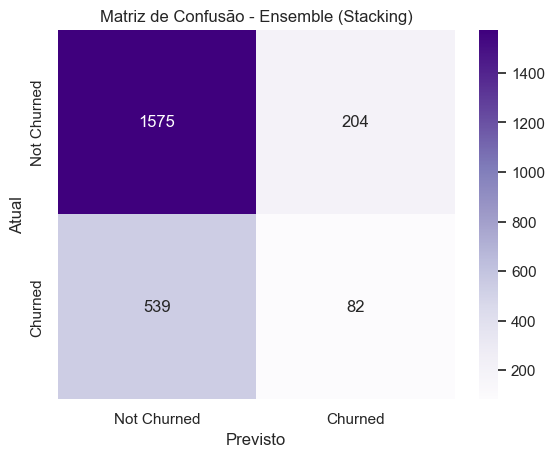

AttributeError: 'StackingClassifier' object has no attribute 'feature_importances_'

In [ ]:
# ENSEMBLE MODEL WITH STACKING CLASSIFIER

# --- 1. Defina seus modelos base ---
# É importante que os modelos não estejam treinados ainda.

# Lembre-se do parâmetro de balanceamento para Regressão Logística
clf1 = model_lr_smote

# O RandomForest também tem um parâmetro de balanceamento
clf2 = model_rf_smote

# Calcule o scale_pos_weight para o XGBoost
clf3 = model_xgb_smote

# Lista de estimadores base
base_estimators = [
    ('lr', clf1),
    ('rf', clf2),
    ('xgb', clf3)
]


# --- 2. Defina o Meta-Modelo (Final Estimator) ---
# Uma Regressão Logística é uma escolha padrão e muito boa.
meta_model = LogisticRegression()

# --- 3. Crie o Stacking Classifier ---
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=15 # Usa validação cruzada para gerar as previsões para treinar o meta-modelo
)

# --- 4. Treine e avalie ---
print("Treinando o modelo de ensemble (Stacking)...")
stacking_model.fit(X_train_resampled, y_train_resampled)
print("Treinamento concluído!")

y_pred_stacking = stacking_model.predict(X_test)

print("\n--- Relatório de Classificação do Ensemble (Stacking) ---")
print(classification_report(y_test, y_pred_stacking, target_names=['Not Churned', 'Churned']))

# Matriz de Confusão
conf_matrix_stacking = confusion_matrix(y_test, y_pred_stacking)
sns.heatmap(conf_matrix_stacking, annot=True, fmt='d', cmap='Purples', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.title('Matriz de Confusão - Ensemble (Stacking)')
plt.ylabel('Atual')
plt.xlabel('Previsto')
plt.show()



--> TREINANDO MODELO PARA PREVER: 'is_churned'

As 10 variáveis mais importantes para prever 'is_churned':
                      Feature  Importance
1              listening_time    0.159221
3                   skip_rate    0.146119
2        songs_played_per_day    0.145460
0                         age    0.132586
19            device_type_Web    0.040015
4       ads_listened_per_week    0.039516
7                gender_Other    0.037307
6                 gender_Male    0.037002
18         device_type_Mobile    0.036050
16  subscription_type_Premium    0.029356

Gráfico salvo como: importancia_variaveis_is_churned.png


Processo de treinamento e análise concluído com sucesso!


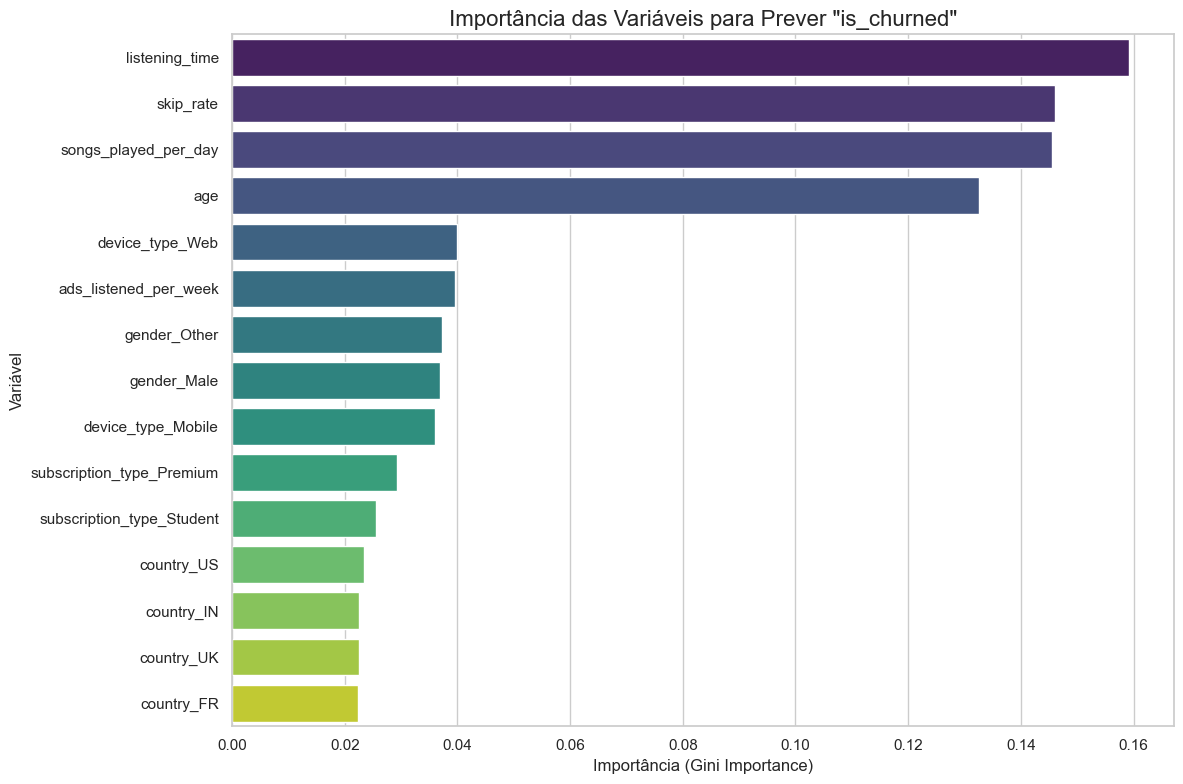

In [99]:
target_columns = ["is_churned"]

# Seleciona todas as colunas do seu df_encoded que NÃO são colunas-alvo
feature_columns = [col for col in df_encoded.columns if col not in target_columns]

# --- 2. Loop para treinar um modelo para cada coluna alvo ---
for target in target_columns:
    print(f"\n{'='*50}")
    print(f"--> TREINANDO MODELO PARA PREVER: '{target}'")
    print(f"{'='*50}")

    # Definindo X (features) e y (alvo) a partir do df_encoded
    X = df_encoded[feature_columns]
    y = df_encoded[target]

    # Criando e treinando o modelo RandomForestClassifier
    importances = model_rf_smote.feature_importances_

    # Criando um DataFrame para visualizar as importâncias de forma ordenada
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"\nAs 10 variáveis mais importantes para prever '{target}':")
    print(importance_df.head(10))

    # --- 4. Gerando um gráfico das variáveis mais importantes ---
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
    plt.title(f'Importância das Variáveis para Prever "{target}"', fontsize=16)
    plt.xlabel('Importância (Gini Importance)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.tight_layout()

    # Salva a imagem com um nome único para cada alvo
    output_filename = f'importancia_variaveis_{target}.png'
    plt.savefig(output_filename)
    print(f"\nGráfico salvo como: {output_filename}")

print("\n\nProcesso de treinamento e análise concluído com sucesso!")